# FLDI / FLM 6AAME – Smart Agriculture

## Einzelprojekt

**Unterrichtszeit:** 08:00–16:00 Uhr  
**Mittagspause:** 11:30–12:30 Uhr  
**Arbeitsform:** Einzelprojekt  
**Endprodukt:** Projektplan, simulierte Agrardaten, FastAPI-Konzept, Datenanalyse, Cybersecurity Review, Flutter Windows Desktop App und Präsentation.

---

## Projektszenario

Du arbeitest als Digital Engineer für einen landwirtschaftlichen Betrieb.  
Der Betrieb möchte ein digitales Überwachungssystem für ein Gewächshaus bzw. eine Smart-Farming-Anlage entwickeln.

Überwacht werden sollen:

- Bodenfeuchtigkeit
- Bodentemperatur
- Lufttemperatur
- Luftfeuchtigkeit
- pH-Wert
- Bewässerungsstatus
- Systemstatus

Die Daten sollen simuliert, analysiert, über eine API bereitgestellt, sicherheitstechnisch bewertet und in einer Flutter-Windows-Desktop-App visualisiert werden.


## Tagesablauf

| Zeit | Phase | Ergebnis |
|---|---|---|
| 08:00–08:30 | Projektauftrag & Projektplanung | Projektsteckbrief, Arbeitspakete, Risiken |
| 08:30–09:30 | Datengenerierung & Datenmodell | CSV-Datei mit mindestens 100 Datensätzen |
| 09:30–10:30 | FastAPI-Konzept / API-Implementierung | REST-API mit Endpunkten |
| 10:30–10:45 | Pause | - |
| 10:45–11:30 | Datenanalyse | Kennzahlen, Cp/Cpk, Diagramme |
| 11:30–12:30 | Mittagspause | - |
| 12:30–13:00 | Cybersecurity Review | Risikomatrix & Gegenmaßnahmen |
| 13:00–13:30 | Zwischenpräsentation | Management Review |
| 13:30–14:45 | Flutter Windows Desktop App | Dashboard-Konzept / Umsetzung |
| 14:45–15:15 | Abschlussdokumentation | Technische Dokumentation |
| 15:15–15:45 | Vorbereitung Abschlusspräsentation | Präsentation finalisieren |
| 15:45–16:00 | Abschlusspräsentation & Demo | Live-Demo / Pitch |


## Lernziele

Nach der Übung kannst du:

1. ein kleines Digitalisierungsprojekt selbstständig planen,
2. Sensordaten für einen landwirtschaftlichen Prozess simulieren,
3. statistische Kennzahlen berechnen und interpretieren,
4. Qualitätsgrenzen und Prozessfähigkeit auf Agrardaten anwenden,
5. eine REST-API fachlich modellieren,
6. grundlegende Cybersecurity-Risiken erkennen,
7. eine passende Flutter-Windows-Desktop-App planen bzw. prototypisch umsetzen,
8. deinen Projektstand professionell präsentieren.


# Phase 1 – Projektplanung (08:00–08:30)

Erstelle einen kurzen Projektsteckbrief.

## Pflichtinhalte

- Projektname
- Zielsetzung
- Stakeholder
- Systemgrenzen
- Funktionale Anforderungen
- Nichtfunktionale Anforderungen
- Arbeitspakete
- Risiken
- Annahmen
- Deliverables

## Aufgabe

Fülle die folgende Vorlage aus.


## Projektsteckbrief

**Projektname:**  
...

**Zielsetzung:**  
...

**Stakeholder:**  
...

**Funktionale Anforderungen:**  
1. ...
2. ...
3. ...

**Nichtfunktionale Anforderungen:**  
1. ...
2. ...
3. ...

**Arbeitspakete:**  
| AP | Beschreibung | Ergebnis |
|---|---|---|
| AP1 | Projektplanung | Projektsteckbrief |
| AP2 | Datengenerierung | CSV-Datensatz |
| AP3 | API | REST-Endpunkte |
| AP4 | Datenanalyse | Kennzahlen & Diagramme |
| AP5 | Cybersecurity | Risikomatrix |
| AP6 | Flutter App | Dashboard |
| AP7 | Präsentation | PPT |

**Top-3-Risiken:**  
| Risiko | Auswirkung | Gegenmaßnahme |
|---|---|---|
| ... | ... | ... |


# Phase 2 – Datengenerierung & Datenmodell (08:30–09:30)

Du simulierst Messdaten einer Smart-Farming-Anlage.

## Datenfelder

- timestamp
- soil_moisture_percent
- soil_temperature_c
- air_temperature_c
- air_humidity_percent
- ph_value
- irrigation_active
- system_status

## Qualitätsgrenzen

Für die Prozessfähigkeitsanalyse verwenden wir den pH-Wert.

- Untere Spezifikationsgrenze LSL = 5.8
- Zielwert = 6.5
- Obere Spezifikationsgrenze USL = 7.2


In [1]:
# Aufgabe: Erzeuge mindestens 100 realistische Datensätze.
# Tipp: Verwende numpy, pandas und datetime.

import numpy as np
import pandas as pd
from datetime import datetime, timedelta

np.random.seed(42)

n = 120
start = datetime.now().replace(second=0, microsecond=0)

timestamps = [start + timedelta(minutes=5*i) for i in range(n)]

# TODO: Passe die Verteilungen sinnvoll an.
soil_moisture = np.random.normal(loc=42, scale=6, size=n)
soil_temperature = np.random.normal(loc=18, scale=2.5, size=n)
air_temperature = np.random.normal(loc=23, scale=3, size=n)
air_humidity = np.random.normal(loc=58, scale=8, size=n)
ph_value = np.random.normal(loc=6.5, scale=0.22, size=n)

# Optional: Baue einzelne Ausreißer ein.
# ph_value[40] = 5.4
# ph_value[85] = 7.5

irrigation_active = soil_moisture < 36
system_status = np.where((ph_value < 5.8) | (ph_value > 7.2), "ALERT", "OK")

df = pd.DataFrame({
    "timestamp": timestamps,
    "soil_moisture_percent": soil_moisture.round(2),
    "soil_temperature_c": soil_temperature.round(2),
    "air_temperature_c": air_temperature.round(2),
    "air_humidity_percent": air_humidity.round(2),
    "ph_value": ph_value.round(2),
    "irrigation_active": irrigation_active,
    "system_status": system_status
})

df.head()


,timestamp,soil_moisture_percent,soil_temperature_c,air_temperature_c,air_humidity_percent,ph_value,irrigation_active,system_status
0,2026-05-30 09:42:00,44.98,19.98,20.62,62.15,6.47,False,OK
1,2026-05-30 09:47:00,41.17,15.73,22.66,70.26,6.29,False,OK
2,2026-05-30 09:52:00,45.89,21.51,24.51,57.13,6.15,False,OK
3,2026-05-30 09:57:00,51.14,14.50,25.60,61.21,6.54,False,OK
4,2026-05-30 10:02:00,40.60,19.47,19.40,63.52,6.33,False,OK


In [2]:
# Speichere den Datensatz als CSV.
csv_path = "smart_agriculture_measurements.csv"
df.to_csv(csv_path, index=False)
csv_path


'smart_agriculture_measurements.csv'

# Phase 3 – FastAPI-Konzept / API-Implementierung (09:30–10:30)

Entwirf eine REST-API für dein Smart-Agriculture-System.

## Pflicht-Endpunkte

| Methode | Endpunkt | Zweck |
|---|---|---|
| GET | /sensors | aktuelle Sensordaten |
| GET | /statistics | berechnete Kennzahlen |
| GET | /alerts | Warnmeldungen |
| POST | /login | Login / Token |
| GET | /health | Systemstatus |

## Aufgabe

Beschreibe unterhalb deine API. Optional kannst du eine echte FastAPI-Datei erstellen.


In [17]:
# Phase 3 – FastAPI-Implementierung
# Die echte API ist als Datei main.py im Projektordner erstellt.
# Zum Starten dieses Services installiere FastAPI und Uvicorn und starte dann:
#   pip install fastapi uvicorn
#   uvicorn main:app --reload
from pathlib import Path
api_file = Path("main.py")
print("FastAPI-Service in main.py erstellt:", api_file.exists())
print(api_file.read_text()[:360] + "\n...")

FastAPI-Service in main.py erstellt: True
from fastapi import FastAPI
from datetime import datetime
from pathlib import Path
from typing import List, Dict
import pandas as pd
import requests

DATA_FILE = Path(__file__).parent / "smart_agriculture_measurements.csv"
app = FastAPI(title="Smart Agriculture API", version="1.0")


def load_measurements() -> pd.DataFrame:
    if not DATA_FILE.exists():
   
...


## API-Design

**Base URL:**  
`http://localhost:8000`

### Endpunkte

#### GET /health
Antwort:
```json
{
  "status": "ok",
  "timestamp": "2026-05-30T10:15:00"
}
```

#### GET /sensors
Antwort:
```json
{
  "count": 10,
  "data": [
    {
      "timestamp": "2026-05-30T10:15:00",
      "soil_moisture_percent": 42.1,
      "soil_temperature_c": 20.8,
      "air_temperature_c": 25.4,
      "air_humidity_percent": 54.2,
      "ph_value": 6.4,
      "irrigation_active": true,
      "system_status": "OK"
    }
  ]
}
```

#### GET /statistics
Antwort:
```json
{
  "sample_count": 100,
  "ph_mean": 6.45,
  "ph_median": 6.50,
  "ph_std": 0.18,
  "ph_variance": 0.03,
  "ph_cp": 1.11,
  "ph_cpk": 0.95,
  "soil_moisture_mean": 42.78,
  "soil_moisture_min": 31.20,
  "soil_moisture_max": 51.00
}
```

#### GET /alerts
Antwort:
```json
{
  "alerts": [
    {
      "timestamp": "2026-05-30T10:15:00",
      "type": "PH_TOO_LOW",
      "severity": "HIGH",
      "message": "pH below lower specification limit"
    }
  ],
  "latest_measurement": {
    "timestamp": "2026-05-30T10:15:00",
    "soil_moisture_percent": 34.8,
    "soil_temperature_c": 21.2,
    "air_temperature_c": 29.1,
    "air_humidity_percent": 45.3,
    "ph_value": 5.7,
    "irrigation_active": true,
    "system_status": "ALERT"
  }
}
```

#### POST /login
Beispiel-Request:
```json
{
  "username": "abc",
  "password": "123"
}
```

Antwort:
```json
{
  "access_token": "demo-token",
  "token_type": "bearer"
}
```


In [14]:
# Die FastAPI-Implementierung steht in main.py.
# Die Endpunkte sind im Projekt wie folgt definiert:
#   GET  /health
#   GET  /sensors
#   GET  /statistics
#   GET  /alerts
#   POST /login
# Verwende die CSV-Datei smart_agriculture_measurements.csv als Datengrundlage.

from pathlib import Path
api_file = Path("main.py")
print(api_file.read_text()[:420] + "\n...")


from fastapi import FastAPI
from datetime import datetime
from pathlib import Path
from typing import List, Dict
import pandas as pd

DATA_FILE = Path(__file__).parent / "smart_agriculture_measurements.csv"
app = FastAPI(title="Smart Agriculture API", version="1.0")


def load_measurements() -> pd.DataFrame:
    if not DATA_FILE.exists():
        raise FileNotFoundError(f"{DATA_FILE} not found")
    df = pd.read_csv(
...


# Phase 4 – Datenanalyse (10:45–11:30)

Berechne für den pH-Wert:

- Mittelwert
- Median
- Varianz
- Standardabweichung
- Cp
- Cpk

## Formeln

Cp = (USL - LSL) / (6 * sigma)

Cpk = min((USL - mean) / (3 * sigma), (mean - LSL) / (3 * sigma))

Interpretation:

- Cpk < 1.00: kritisch
- 1.00 <= Cpk < 1.33: grenzwertig
- Cpk >= 1.33: fähiger Prozess


In [15]:
# Aufgabe: Berechne die Kennzahlen.

LSL = 5.8
USL = 7.2

ph = df["ph_value"]

mean_ph = ph.mean()
median_ph = ph.median()
var_ph = ph.var(ddof=1)
std_ph = ph.std(ddof=1)

cp = (USL - LSL) / (6 * std_ph)
cpk = min((USL - mean_ph) / (3 * std_ph), (mean_ph - LSL) / (3 * std_ph))

result = {
    "mean_ph": round(mean_ph, 3),
    "median_ph": round(median_ph, 3),
    "var_ph": round(var_ph, 4),
    "std_ph": round(std_ph, 4),
    "cp": round(cp, 3),
    "cpk": round(cpk, 3)
}

result


{'mean_ph': np.float64(6.47),
 'median_ph': np.float64(6.465),
 'var_ph': np.float64(0.0426),
 'std_ph': np.float64(0.2065),
 'cp': np.float64(1.13),
 'cpk': np.float64(1.082)}

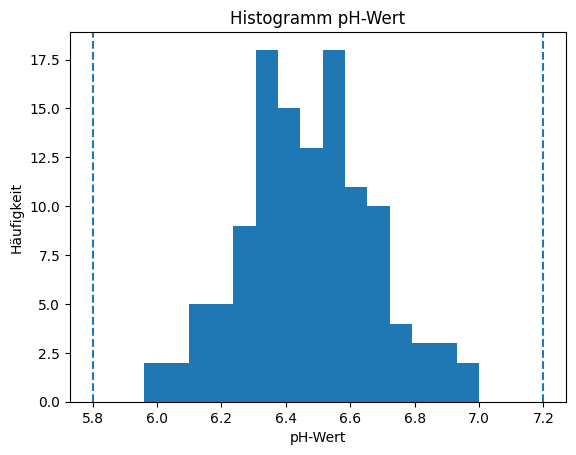

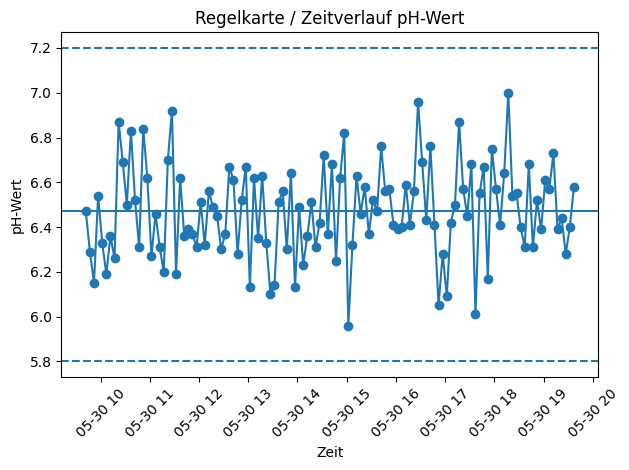

In [16]:
# Visualisierung: Histogramm und einfache Regelkarte.

import matplotlib.pyplot as plt

plt.figure()
plt.hist(ph, bins=15)
plt.axvline(LSL, linestyle="--")
plt.axvline(USL, linestyle="--")
plt.title("Histogramm pH-Wert")
plt.xlabel("pH-Wert")
plt.ylabel("Häufigkeit")
plt.show()

plt.figure()
plt.plot(df["timestamp"], ph, marker="o")
plt.axhline(LSL, linestyle="--")
plt.axhline(USL, linestyle="--")
plt.axhline(mean_ph, linestyle="-")
plt.title("Regelkarte / Zeitverlauf pH-Wert")
plt.xlabel("Zeit")
plt.ylabel("pH-Wert")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Phase 5 – Cybersecurity Review (12:30–13:00)

Bewerte dein System aus Sicht der Cybersecurity.

## Mindestanforderung

Dokumentiere mindestens 5 Risiken.

Beispiele:

- Keine Authentifizierung
- Fehlende Autorisierung
- Hardcodierte Secrets
- Keine Eingabevalidierung
- Keine Rate Limits
- Docker-Container läuft als root
- Zu viele offene Ports
- Keine Logs
- Keine Trennung von Rollen

## Aufgabe

Fülle die Risikomatrix aus.


## Risikomatrix

| Nr. | Schwachstelle | Risiko | Eintritt | Auswirkung | Maßnahme |
|---:|---|---|---|---|---|
| 1 | ... | ... | niedrig/mittel/hoch | niedrig/mittel/hoch | ... |
| 2 | ... | ... | ... | ... | ... |
| 3 | ... | ... | ... | ... | ... |
| 4 | ... | ... | ... | ... | ... |
| 5 | ... | ... | ... | ... | ... |


# Phase 6 – Zwischenpräsentation (13:00–13:30)

Erstelle eine PowerPoint mit 5–7 Folien.

## Zielgruppe

Geschäftsführung des landwirtschaftlichen Betriebs.

## Pflichtfolien

1. Projektziel
2. Systemarchitektur
3. Aktueller Umsetzungsstand
4. Erste Analyseergebnisse
5. Cybersecurity-Risiken
6. Nächste Schritte

## Dauer

5 Minuten Präsentation.


# Phase 7 – Flutter Windows Desktop App (13:30–14:45)

Entwickle oder plane eine Flutter-Windows-Desktop-App.

## Mindestfunktionen

- Anzeige aktueller Sensordaten
- Anzeige von Mittelwert, Standardabweichung, Cp und Cpk
- Anzeige von Warnungen
- Systemstatus: OK / Warning / Critical

## Empfohlene Screens

1. Dashboard
2. Analyse
3. Security / Alerts
4. Projektinfo

## Beispielhafte Widget-Struktur

```dart
Column(
  children: [
    Text("Smart Agriculture Dashboard"),
    Text("pH Mittelwert: 6.51"),
    Text("Cpk: 1.21"),
    Text("Status: Warning"),
  ],
)
```


# Phase 8 – Abschlussdokumentation (14:45–15:15)

Erstelle eine kurze technische Dokumentation.

## Pflichtkapitel

1. Projektziel
2. Datenmodell
3. API-Design
4. Datenanalyse
5. Cybersecurity Review
6. Flutter-App
7. Offene Punkte
8. Lessons Learned


# Phase 9 – Abschlusspräsentation & Demo (15:45–16:00)

## Pflichtinhalte

- Projektziel
- Architektur
- wichtigste Analyseergebnisse
- Cybersecurity-Findings
- Flutter-App oder App-Konzept
- Lessons Learned

## Abschlussfrage

Was wäre der nächste sinnvolle Entwicklungsschritt, wenn das Projekt morgen weitergeführt würde?


# Abgabe

Gib am Ende ab:

1. ausgefülltes Notebook
2. CSV-Datei
3. API-Konzept oder FastAPI-Code
4. Flutter-Projekt oder App-Skizze
5. PowerPoint-Zwischenpräsentation
6. Abschlussdokumentation

## Bewertung

| Bereich | Punkte |
|---|---:|
| Projektplanung | 10 |
| Datengenerierung | 10 |
| API | 15 |
| Datenanalyse | 15 |
| Cybersecurity | 15 |
| Flutter Windows App | 15 |
| Dokumentation | 10 |
| Zwischenpräsentation | 5 |
| Abschlusspräsentation | 5 |
| Gesamt | 100 |
